# TomTex demo notebook for instron analysis packages.


<div class="alert alert-block alert-info"

<b>First</b>, download the packages from Github.

You may want to first decide which directory in which to save the packages. Either navigate to it in your terminal or add that path in the following command.

To retrieve the code, or "clone" the "repository", execute the following command in your terminal:

git clone https://github.com/tomtex-zach/instron_analysis_repo.git

or with your specified local directory:

git clone https://github.com/tomtex-zach/instron_analysis_repo.git /Your/Project/here/

</div>

<div class="alert alert-block alert-info">
<b>Next</b>, install the package to your machine using pip. Either navigate to the repo directory (or add in command line) and execute the following command:

pip install .

or 

pip install /Your/Project/here/package_repo

</div>

<div class="aler alert-block alert-success">
If installation was a success, you can now use the package!

</div>

In [1]:
# Using this package will work best in a Jupyter notebook (or Python script) that is located in the same directory as your data. 
# This way, you can organize your experiments with your data alongside outputs like stats data and plots.
# To start, move to the directory containing your data, open a notebook and download the package.
# Giving the package an alias such as "ia" is used for brevity.

import instron_analysis as ia

# While we're at it, lets include any other packages we may wish to include:

import pandas as pd
import seaborn as sns
sns.set()

<div class="alert alert-block alert-warning"


Within this package, tools such as pandas and matplotlib are already installed, so they can be accessed as needed within its commands. Since they are not installed globally, you won't have access to them for bespoke uses, for example if you wish to plot something separately or execute any pandas operations.

In [2]:
# The help command will print out the description of the package if you need any reminders.

help(ia)

Help on package instron_analysis:

NAME
    instron_analysis - Created on Wed Sep  3 16:30:05 2025

DESCRIPTION
    This package contains functions for formatting instron data files, adjusting them
    by calculating Elongation (%), Load (MPa) etc and calculating properties such as
    Youngs modulus, yield stress/strain, max elongation/tenacity and toughness.

    A quick description of the functions:

        format_file -- input filepath of raw data, file is duplicated as the "backup"
            and data file is replaced correct format for the rest of the code.
        process -- input filepath to formatted data file and coupon metadata and
            get list of DataFrames for each individual test, as well as list of tuples
            linking sample names to their thicknesses.
        mars_model, trim_end, trim, find_modulus, offset_yield all help to calculate
            properties. These are used in the following functions and probably have no
            use being used separa

## Module 1: raw_data_formatter 
### -format_file
### -process

Typically, you will need to reformat the data file that is output from the instron machine.

First, input the filename as a string into <b>ia.format_file()</b>. The data is overwritten in its new format, but first a backup is created called "backup_..." in case you which to retrieve it in its original form. 

To use process, you will need an additional csv file containing the test's metadata to your working directory. Make the file in Excel/Sheets or make your csv directly given the following guidelines: \
sample_name,d \
sample-1,"0.12,0.13,0.14" \
etc

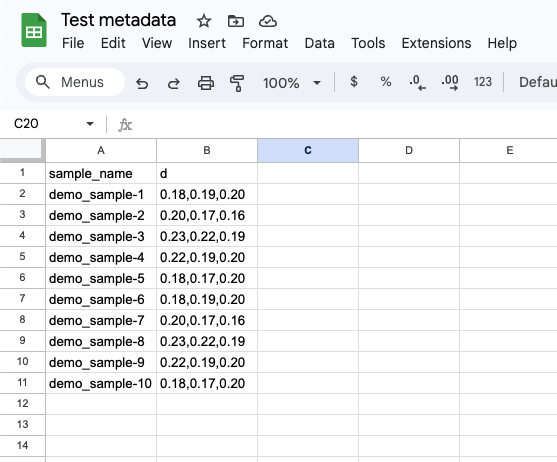

Add first the data file and then the metadata into <b>ia.process()</b>. This will output a list containing a Pandas DataFrame for each individual test and a list of tuples linking a name of each sample to its measured thickness.

In [3]:
# As you can see here, pandas is unable to parse through the csv file as is

import pandas as pd
# pd.read_csv('demo data.csv')

In [4]:
# Instead, format the file here.

ia.format_file('demo data.csv')

Original file demo data.csv duplicated to backup_demo data.csv


In [5]:
# Input newly formatted data and metadata.

dfs, stp = ia.process('demo data.csv', 'Test metadata - Package demo.csv')

In [6]:
# We can see this data file contained 30 tests. As we can see from the metadata file, this is made up of 10
# samples with 3 replicates each.

len(dfs)

34

In [7]:
# To look at one DataFrame individually:

dfs[29]

,Position (mm),Force (N)
0,0.00,0.000893
1,0.01,0.001573
2,0.06,0.011572
3,0.08,0.017408
4,0.10,0.109526
...,...,...
4437,91.40,-0.007365
4438,91.41,0.005992
4439,91.44,-0.011315
4440,91.49,-0.017508


<Axes: >

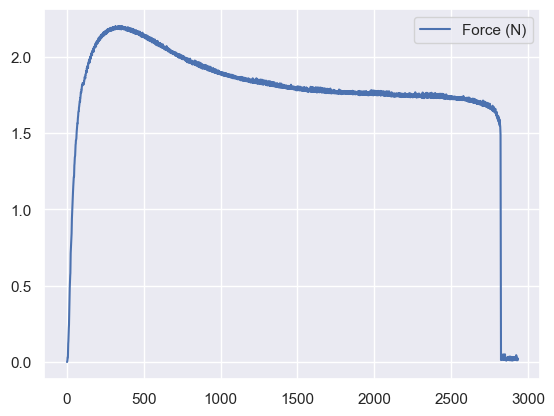

In [8]:
# Or even plot it! (With the DataFrames "plot" attribute)

dfs[4].plot()

In [9]:
# The "sample thickness pairs" 

stp

[['demo_sample-1', np.float64(0.18)],
 ['demo_sample-1', np.float64(0.19)],
 ['demo_sample-1', np.float64(0.2)],
 ['demo_sample-2', np.float64(0.2)],
 ['demo_sample-2', np.float64(0.17)],
 ['demo_sample-2', np.float64(0.16)],
 ['demo_sample-3', np.float64(0.23)],
 ['demo_sample-3', np.float64(0.22)],
 ['demo_sample-3', np.float64(0.19)],
 ['demo_sample-4', np.float64(0.22)],
 ['demo_sample-4', np.float64(0.19)],
 ['demo_sample-4', np.float64(0.2)],
 ['demo_sample-5', np.float64(0.18)],
 ['demo_sample-5', np.float64(0.17)],
 ['demo_sample-5', np.float64(0.2)],
 ['demo_sample-6', np.float64(0.18)],
 ['demo_sample-6', np.float64(0.19)],
 ['demo_sample-6', np.float64(0.2)],
 ['demo_sample-7', np.float64(0.2)],
 ['demo_sample-7', np.float64(0.17)],
 ['demo_sample-7', np.float64(0.16)],
 ['demo_sample-8', np.float64(0.23)],
 ['demo_sample-8', np.float64(0.22)],
 ['demo_sample-8', np.float64(0.19)],
 ['demo_sample-9', np.float64(0.22)],
 ['demo_sample-9', np.float64(0.19)],
 ['demo_sample-9',

## Module 2: property_calculator
### -mars_model, trim_end, trim, find_modulus, offset_yield, adjust_df
### -analyze, data_table

This set of functions are nested in a way that it is only necessary to call <b>ia.data_table()</b> to process each DataFrame in the entire set and output the results. This function maps all of the other functions in the module to apply them to each sample test along with its needed sample thickness. 

The inputs needed are the list of DataFrames, the sample thickness pairs, estimated gauge length (EGL), and width of the samples. (If you used different EGL and sample widths, supply a list). 

The outputs of this function are a table of the results of each run, a table of the results averaged based on samples, and a table of their standard deviations.

If you wish to analyze one individually, you may use <b>ia.analyze()</b>. Pressing "shift+tab" in the open parantheses of a function will display a brief description and the needed arguments for any given function. So if you wish to use this or any given function individually, you can check the inputs there.

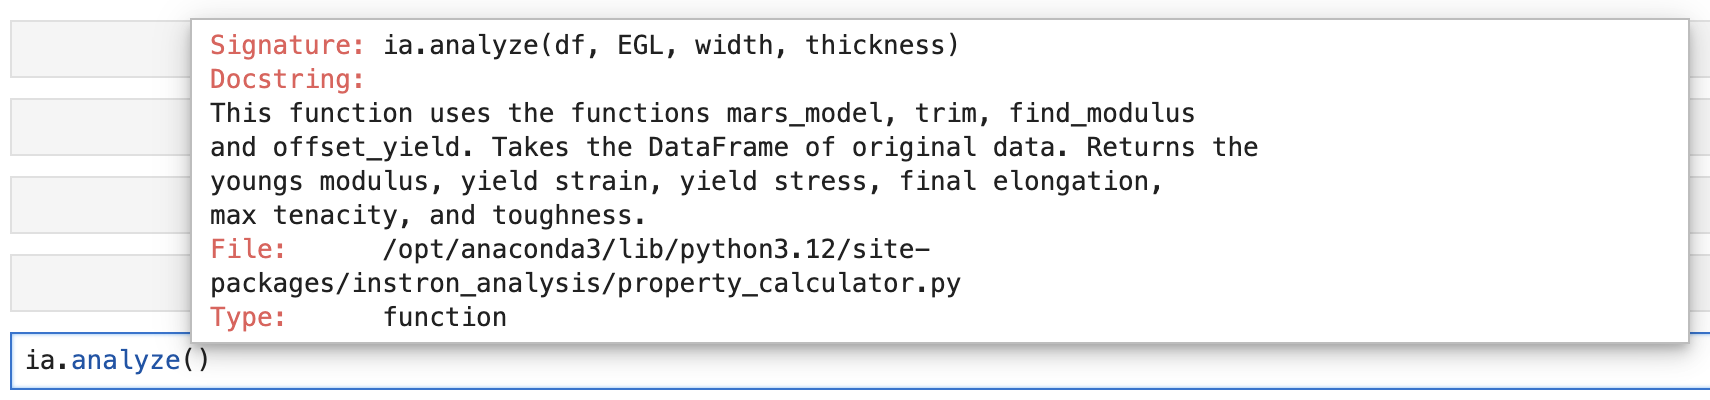

In [21]:
%load_ext autoreload
%autoreload 2

In [54]:
# Use the variables we have saved from before, dfs (our individual tests) and stp (list of sample thickness pairs)

data, avg, st = ia.data_table(dfs,stp,4.7,8.4)

/Users/TomTex/Git/instron_analysis_repo/src/instron_analysis/property_calculator.py:191: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[high_mask]


In [55]:
data

,modulus,yield strain,yield stress,elongation,tenacity,second yield,toughness
demo_sample-1,0.053277,18.888968,0.950343,1353.191528,1.664055,121.914902,1820.656390
demo_sample-1,0.041595,18.067104,0.743181,2012.340576,1.386859,117.021286,2161.825121
demo_sample-1,0.039862,18.896356,0.745278,1471.276611,1.324657,121.276596,1550.823143
demo_sample-2,0.036044,18.242430,0.650323,1673.404297,1.168262,109.574471,1564.677691
demo_sample-2,0.047248,18.503632,0.864813,1266.595703,1.559454,119.787239,1627.688756
demo_sample-2,0.056347,16.513945,0.919244,1210.851074,1.650915,113.829788,1652.566973
demo_sample-3,0.029436,19.821667,0.577574,1899.361816,0.968593,115.957451,1422.819342
demo_sample-3,0.030103,17.689647,0.526490,1814.255371,0.958779,119.787239,1356.490132
demo_sample-3,0.034499,18.665600,0.637042,1911.915039,1.194631,114.042557,1818.994013
demo_sample-4,0.023994,19.436664,0.461572,1820.425659,0.840591,114.893631,1167.979266


In [56]:
avg

,modulus,yield strain,yield stress,elongation,tenacity,second yield,toughness
demo_sample-1,0.045,18.617,0.813,1612.270020,1.459,120.070999,1844.435
demo_sample-10,0.041,22.325,0.891,1961.135010,1.577,127.943001,2329.026
demo_sample-2,0.047,17.753,0.811,1383.616943,1.460,114.397003,1614.978
demo_sample-3,0.031,18.726,0.580,1875.177002,1.041,116.596001,1532.768
demo_sample-4,0.033,17.309,0.545,1415.531982,1.017,115.745003,1109.291
demo_sample-5,0.037,21.291,0.783,1731.063965,1.370,121.986000,1857.575
demo_sample-6,0.031,20.487,0.630,1730.708984,1.134,119.644997,1522.417
demo_sample-7,0.041,18.175,0.736,1798.084961,1.344,117.660004,1911.369
demo_sample-8,0.035,19.034,0.658,1689.219971,1.209,116.596001,1557.371
demo_sample-9,0.026,22.343,0.585,1480.780029,1.075,120.638000,1239.310


In [57]:
st

,modulus,yield strain,yield stress,elongation,tenacity,second yield,toughness
demo_sample-1,0.007,0.477,0.119,351.466003,0.181,2.660,306.194
demo_sample-10,0.007,3.196,0.040,255.223007,0.156,2.391,229.893
demo_sample-2,0.010,1.081,0.142,252.505997,0.256,5.130,45.302
demo_sample-3,0.003,1.067,0.055,53.132000,0.133,2.925,250.088
demo_sample-4,0.009,2.179,0.082,377.209015,0.161,1.662,67.689
demo_sample-5,0.003,1.720,0.074,70.221001,0.118,2.777,85.431
demo_sample-6,0.005,3.417,0.078,11.912000,0.077,6.500,110.245
demo_sample-7,0.002,2.392,0.094,99.166000,0.099,10.657,199.251
demo_sample-8,0.002,2.769,0.136,413.151001,0.204,3.344,96.651
demo_sample-9,0.003,0.547,0.061,234.740997,0.144,2.878,23.366


In [58]:
dfs[33]

,Position (mm),Force (N)
0,0.00,0.001785
1,0.01,0.000379
2,0.05,0.003816
3,0.08,-0.003292
4,0.09,0.020834
...,...,...
383,7.86,-0.001707
384,7.88,-0.000547
385,7.93,-0.009865
386,7.94,-0.001216


In [ ]:
# These can be used together for visualizing data such as in a bar plot with error bars:

avg['modulus'].plot.bar(yerr = st, 
                        rot = 45,
                        title = 'Package demo, modulus results')

## Module 3: full_plot
### -plot_data

Finally, all the DataFrames can be plotted in total with <b>ia.plot_data()</b>. The needed inputs are the DataFrames, a title, number of replicates, sample thickness pairs, and if you would like to save this figure, set save = True. 

For best results, it helps to have a consistent amount of replicates per sample so they can all be color coded. 

In [ ]:
# Plot the data and save it to your experimental folder!

ia.plot_data(dfs,'Package demo tensile graph',3,stp,save = False)

In [49]:
hi = dfs[1]['Elongation'].loc[dfs[1]['Load (MPa)'] == dfs[1]['Load (MPa)'].max()].iloc[0]

In [53]:
hi

np.float32(143.61702)